In [23]:
import torch as tr
from torch import nn
device =  "cuda" if tr.cuda.is_available() else "cpu"
device


'cpu'

## We are using food101 dataset here for custom dataset model creation

In [59]:
import requests 
import zipfile
from pathlib import Path

data_path = Path("data/")

image_path = data_path / "pizza_steak_sushi" 

if image_path.is_dir():
    print(f"{image_path} direcrtory already exists")
else:
    print(f"{image_path} directory does not exist, creating a new one")
    image_path.mkdir(parents = True, exist_ok = True)


data\pizza_steak_sushi direcrtory already exists


In [25]:
with open(data_path / "pizza_steak_sushi.zip" , "wb") as f:
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/baa27b691617461c173ecf3439793cd8cde74e13/data/pizza_steak_sushi.zip")
    print("Downloading pizza_steak_sushi.zip")

In [5]:
# with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
#     print("Extracting pizza_steak_sushi.zip")
#     zip_ref.extractall(image_path)

In [60]:
import os 
def walk_through_dir(dir_path):
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")


walk_through_dir(image_path)

There are 4 directories and 0 images in 'data\pizza_steak_sushi'.
There are 0 directories and 0 images in 'data\pizza_steak_sushi\pissa_steak_sushi'.
There are 0 directories and 1 images in 'data\pizza_steak_sushi\pizza_custom'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi\test'.
There are 0 directories and 25 images in 'data\pizza_steak_sushi\test\pizza'.
There are 0 directories and 19 images in 'data\pizza_steak_sushi\test\steak'.
There are 0 directories and 31 images in 'data\pizza_steak_sushi\test\sushi'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi\train'.
There are 0 directories and 78 images in 'data\pizza_steak_sushi\train\pizza'.
There are 0 directories and 75 images in 'data\pizza_steak_sushi\train\steak'.
There are 0 directories and 72 images in 'data\pizza_steak_sushi\train\sushi'.


In [61]:
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(WindowsPath('data/pizza_steak_sushi/train'),
 WindowsPath('data/pizza_steak_sushi/test'))

data\pizza_steak_sushi\test\sushi\2394442.jpg
sushi
408
512


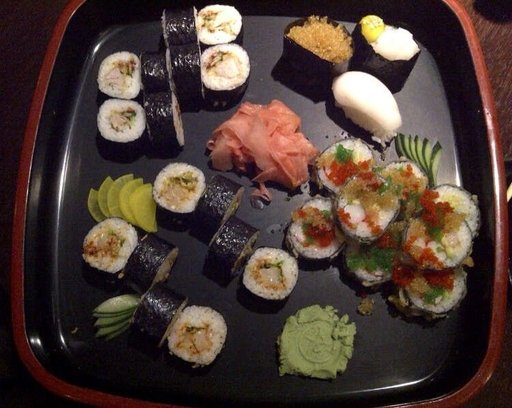

In [62]:
import random
from PIL import Image

random.seed(42)
image_path_list = list(image_path.glob("*/*/*.jpg"))
random_image_path = random.choice(image_path_list)
print(random_image_path)

image_class = random_image_path.parent.name
print(image_class)
img = Image.open(random_image_path)

print(img.height)
print(img.width)
img

(408, 512, 3)


(np.float64(-0.5), np.float64(511.5), np.float64(407.5), np.float64(-0.5))

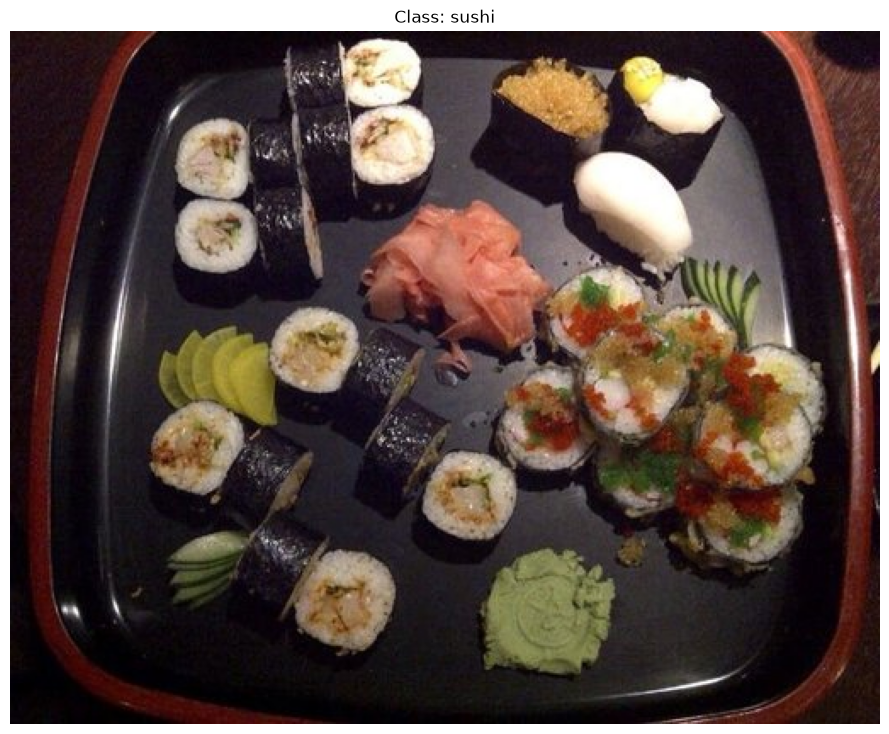

In [63]:
import numpy as np
import matplotlib.pyplot as plt
img_as_array = np.array(img)
plt.figure(figsize = (150, 9))
plt.imshow(img_as_array)
print(img_as_array.shape)
plt.title(f"Class: {image_class}")
plt.axis(False)

In [64]:
img_as_array[1]

array([[35, 15, 17],
       [32, 12, 14],
       [31, 11, 13],
       ...,
       [21, 12, 17],
       [19, 10, 15],
       [19, 10, 15]], shape=(512, 3), dtype=uint8)

In [65]:
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms


In [66]:
data_transform = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.ToTensor()
])

In [67]:
data_transform(img).shape

torch.Size([3, 64, 64])

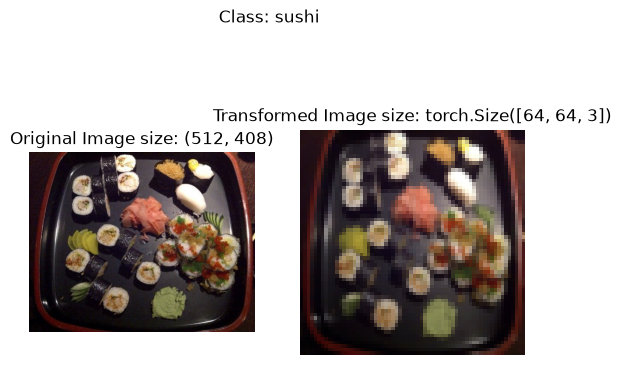

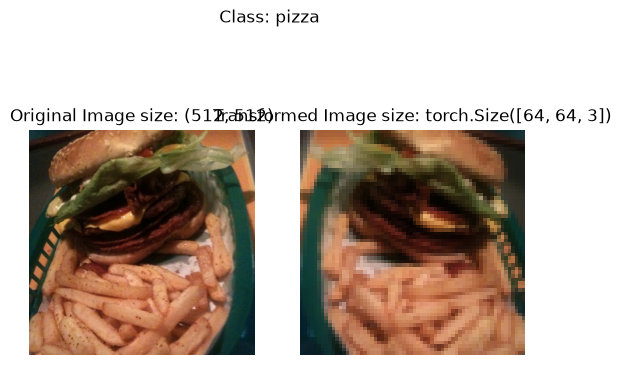

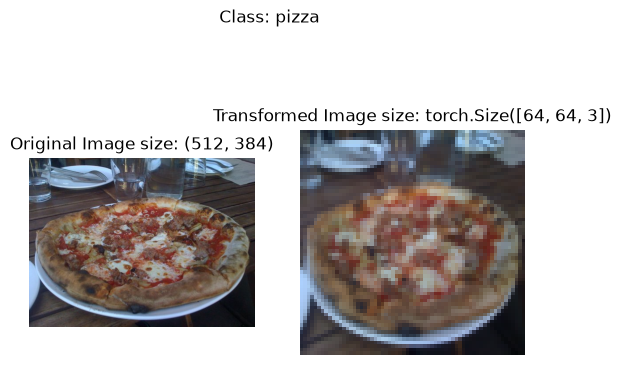

In [68]:
def plot_transformed_image(image_path, transform, n = 3, seed = 42):
    if seed:
        random.seed(seed)
    random_image_paths = random.sample(image_path, k = n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax= plt.subplots(nrows = 1, ncols = 2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original Image size: {f.size}")
            ax[0].axis(False)
            transformed_image = transform(f).permute(1, 2, 0)

            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed Image size: {transformed_image.size()}")
            ax[1].axis("off")
            fig.suptitle(f"Class: {image_path.parent.name}")

plot_transformed_image(image_path_list, data_transform, n = 3, seed = 42)

In [69]:
image_path = data_path / "pizza_steak_sushi" /"pizza_custom"

In [70]:
train_data = datasets.ImageFolder(root = train_dir, transform = data_transform, target_transform = None)
test_data = datasets.ImageFolder(root = test_dir, transform = data_transform, target_transform = None)
print(train_data, test_data)

Dataset ImageFolder
    Number of datapoints: 225
    Root location: data\pizza_steak_sushi\train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           ) Dataset ImageFolder
    Number of datapoints: 75
    Root location: data\pizza_steak_sushi\test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )


In [71]:
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [72]:
class_dict = train_data.class_to_idx
class_dict


{'pizza': 0, 'steak': 1, 'sushi': 2}

In [73]:
train_data[1]
img, label = train_data[0][0], train_data[0][1]

img, label, img.shape, img.dtype,type(label), label

(tensor([[[0.1137, 0.1020, 0.0980,  ..., 0.1255, 0.1216, 0.1176],
          [0.1059, 0.0980, 0.0980,  ..., 0.1294, 0.1294, 0.1294],
          [0.1020, 0.0980, 0.0941,  ..., 0.1333, 0.1333, 0.1333],
          ...,
          [0.1098, 0.1098, 0.1255,  ..., 0.1686, 0.1647, 0.1686],
          [0.0902, 0.0941, 0.1098,  ..., 0.1686, 0.1647, 0.1686],
          [0.0863, 0.0863, 0.0980,  ..., 0.1686, 0.1647, 0.1647]],
 
         [[0.0745, 0.0706, 0.0745,  ..., 0.0588, 0.0588, 0.0588],
          [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
          [0.0706, 0.0745, 0.0745,  ..., 0.0706, 0.0706, 0.0706],
          ...,
          [0.1255, 0.1333, 0.1373,  ..., 0.2510, 0.2392, 0.2392],
          [0.1098, 0.1176, 0.1255,  ..., 0.2510, 0.2392, 0.2314],
          [0.1020, 0.1059, 0.1137,  ..., 0.2431, 0.2353, 0.2275]],
 
         [[0.0941, 0.0902, 0.0902,  ..., 0.0157, 0.0196, 0.0196],
          [0.0902, 0.0863, 0.0902,  ..., 0.0196, 0.0157, 0.0196],
          [0.0902, 0.0902, 0.0902,  ...,

torch.Size([64, 64, 3]) torch.float32 <class 'int'> 0


Text(0.5, 1.0, '0')

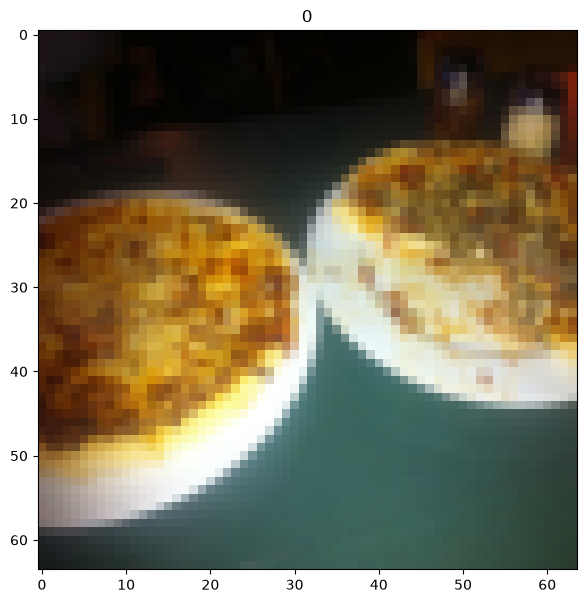

In [74]:
img_permute = img.permute(1, 2, 0)
print(img_permute.shape, img_permute.dtype, type(label), label)
plt.figure(figsize = (10, 7))
plt.imshow(img_permute)
plt.title(label)


In [75]:
# turn loaded images into dataloader
Batch_size = 32
train_dataloader = DataLoader(dataset = train_data, batch_size = Batch_size, num_workers = 1,  shuffle = True)
test_dataloader = DataLoader(dataset= test_data, batch_size = Batch_size, num_workers = 1, shuffle = False)


In [76]:
len(train_dataloader), len(test_dataloader), len(train_data)

(8, 3, 225)

In [77]:
image, label = next(iter(train_dataloader))
print(f"Image batch shape: {image.size()} \nLabel batch shape: {label.size()}")

Image batch shape: torch.Size([32, 3, 64, 64]) 
Label batch shape: torch.Size([32])


In [78]:
from typing import List, Dict, Tuple

In [79]:
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [80]:
## set the target directory 

target_directory = train_dir
print(f"Target Directory: {target_directory}")

Target Directory: data\pizza_steak_sushi\train


In [81]:
list(os.scandir(target_directory))

[<DirEntry 'pizza'>, <DirEntry 'steak'>, <DirEntry 'sushi'>]

In [82]:
def find_class(directory)-> Tuple[List[str], Dict[str, int]]:
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
    class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
    if not classes:
        raise FileNotFoundError(f"No class directories found in {directory}.")
    return classes, class_to_idx

In [83]:
# find_class(target_directory)
find_class(test_dir)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [84]:
import pathlib

In [85]:
class imagefoldercustom(Dataset):
    def __init__(self, targ_dir, transform):
        self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg"))
        self.transform = transform
        self.classes, self.class_to_idx = find_class(targ_dir)

    def load_image(self, patt):
        image_path = self.paths
        return Image.open(image_path)

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        img = self.load_image(index)
        class_name = self.paths[index].parent.name
        class_idx = self.class_to_idx[class_name]
        if self.transform:
            img = self.transform(img)
        return img, class_idx
        
        
        

In [86]:
train_transform = transforms.Compose([
    transforms.Resize(size = (64, 64)),
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.ToTensor()

])

test_transform = transforms.Compose([
    transforms.Resize(size = (64, 64)),
    transforms.ToTensor()
])

In [87]:
train_data_custom = imagefoldercustom(targ_dir = train_dir, transform = train_transform)
test_data_custom = imagefoldercustom(targ_dir = test_dir, transform = test_transform)

In [88]:
len(test_data_custom), len(train_data_custom)
# len(train_data), len(test_data)

(75, 225)

In [89]:
def display_random_image(dataset, classes = None, n = 10, display_shape = True,  seed = None):
    if n > 10:
        n = 10 
        display_shape = False
        print(f"for display purpose n should'nt be greater")
    if seed: 
        random.seed(seed)

    random_sample_idx = random.sample(range(len(dataset)), k = n)
    plt.figure(figsize = (16, 9))
    for i, targ_sample in enumerate(random_sample_idx):
        targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]
        targ_image_adjust = targ_image.permute(1, 2, 0)
        plt.subplot(1, n, i + 1,)
        plt.imshow(targ_image_adjust)
        plt.axis("off")
        if classes:
            title = f" Class: {classes[targ_label]}"
            if display_shape:
                title += f"\n Shape: {targ_image_adjust.shape}"
        plt.title(title)

In [91]:
# display_random_image(train_data_custom, classes = class_names, n = 5,  seed = 42)

In [92]:
class TinyVGG(nn.Module):
    def __init__(self, input_shape, hidden_units, output_shape) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels = input_shape, out_channels= hidden_units, kernel_size = 3, stride = 1, padding = 0),
            nn.ReLU(),
            nn.Conv2d(in_channels = hidden_units, out_channels= hidden_units, kernel_size = 3, stride = 1, padding = 0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size= 2, stride  = 2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels= hidden_units, out_channels = hidden_units, kernel_size= 3, stride = 1, padding = 0),
            nn.ReLU(),
            nn.Conv2d(in_channels = hidden_units, out_channels = hidden_units, kernel_size = 3, stride = 1, padding =0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size= 2, stride  = 2)
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(in_features = hidden_units* 13*13, out_features = output_shape))


    def forward(self, x):
        x = self.conv_block_1(x)
        print(x.shape)
        x = self.conv_block_2(x)
        print(x.shape)
        x = self.classifier(x)
        return x
        # return self.conv_block_1(self.conv_block_2(self.classifier(x)))

In [93]:
tr.manual_seed(42)
model_0 = TinyVGG(input_shape= 3, hidden_units=  10, output_shape = len(class_names)).to(device)

model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

In [94]:
# try a forward pass on a single image

image_batch , label_batch = next(iter(train_dataloader))
image_batch.shape, label_batch.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [95]:
model_0(image_batch.to(device))

torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])


tensor([[ 2.0795e-02, -1.9510e-03,  9.5213e-03],
        [ 1.9347e-02,  3.1597e-03,  7.4474e-03],
        [ 1.7695e-02,  1.0282e-03,  9.4975e-03],
        [ 2.1068e-02, -2.6110e-03,  1.0277e-02],
        [ 1.9939e-02,  6.9127e-04,  1.0778e-02],
        [ 2.1281e-02,  2.0434e-03,  5.0046e-03],
        [ 2.0996e-02,  1.6417e-04,  1.2481e-02],
        [ 2.1566e-02, -1.9607e-03,  9.7175e-03],
        [ 2.4500e-02, -4.7905e-03,  8.5394e-03],
        [ 1.9275e-02, -1.7612e-04,  8.9663e-03],
        [ 1.9972e-02, -2.9622e-03,  8.2557e-03],
        [ 2.2318e-02, -2.1642e-03,  9.4428e-03],
        [ 2.1851e-02, -3.7225e-03,  8.3784e-03],
        [ 2.2881e-02, -1.7559e-03,  1.0299e-02],
        [ 2.1635e-02, -4.3995e-03,  9.4989e-03],
        [ 2.2589e-02, -3.4084e-03,  1.0640e-02],
        [ 2.0182e-02, -2.1775e-03,  9.5757e-03],
        [ 2.1698e-02, -2.7457e-03,  8.4965e-03],
        [ 1.9974e-02, -3.3528e-07,  8.4496e-03],
        [ 1.8308e-02,  1.6379e-03,  8.5491e-03],
        [ 1.7433e-02

In [96]:
from torchinfo import summary


summary(model_0, input_size = [1, 3, 64, 64])


torch.Size([1, 10, 30, 30])
torch.Size([1, 10, 13, 13])


Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 30, 30]           --
│    └─Conv2d: 2-1                       [1, 10, 62, 62]           280
│    └─ReLU: 2-2                         [1, 10, 62, 62]           --
│    └─Conv2d: 2-3                       [1, 10, 60, 60]           910
│    └─ReLU: 2-4                         [1, 10, 60, 60]           --
│    └─MaxPool2d: 2-5                    [1, 10, 30, 30]           --
├─Sequential: 1-2                        [1, 10, 13, 13]           --
│    └─Conv2d: 2-6                       [1, 10, 28, 28]           910
│    └─ReLU: 2-7                         [1, 10, 28, 28]           --
│    └─Conv2d: 2-8                       [1, 10, 26, 26]           910
│    └─ReLU: 2-9                         [1, 10, 26, 26]           --
│    └─MaxPool2d: 2-10                   [1, 10, 13, 13]           --
├─Sequentia

In [97]:
def train_step(model, dataloader, loss_fn, optimizer, device=device):
    model.train(),

    train_loss, train_acc = 0, 0
    for batch, (x, y) in enumerate(dataloader):
        x, y = x.to(device), y.to(device)

        y_pred = model(x)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        y_pred_class = tr.argmax(tr.softmax(y_pred, dim = 1), dim = 1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc 




In [98]:
def test_step(model, dataloader, loss_fn, device = device):
    model.eval(),
    test_loss, test_acc = 0, 0
    with tr.inference_mode():
        for batch, (x, y) in enumerate(dataloader):
            x, y = x.to(device), y.to(device)

            test_pred_logits = model(x)
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()
            test_pred_labels = test_pred_logits.argmax(dim = 1)
            test_acc += ((test_pred_labels == y).sum().item()/ len(test_pred_labels))

    test_loss = test_loss/ len(dataloader)
    test_acc = test_acc/ len(dataloader)
    return test_loss, test_acc


In [99]:
from tqdm.auto import tqdm 


def train(model, train_dataloader, test_dataloader, optimizer, loss_fn, epochs = 5, device= device):
    results = {"train_loss":[],
               "train_acc":[],
               "test_loss":[],
               "test_acc":[]}

    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model = model, dataloader = train_dataloader, loss_fn = loss_fn, optimizer= optimizer, device = device)
        test_loss, test_acc = test_step(model = model , dataloader = test_dataloader, loss_fn = loss_fn, device = device)

        print(f"Epcoch: {epoch} | Train Loss: {train_loss}  | Train Accuracy :{train_acc} | Test  Loss : {test_loss} | Test Accuracy :{test_acc}")

        results["train_loss"].append(train_loss)
        results["train_acc"].append(test_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)
    return results


c:\Users\dynam\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [100]:
# train and evaluate model_0

tr.manual_seed(42)
tr.cuda.manual_seed(42)

num_epochs = 5

model_0 = TinyVGG(input_shape = 3, hidden_units= 10, output_shape=len(train_data.classes)).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = tr.optim.Adam(params = model_0.parameters(), lr = 0.001)
from timeit import default_timer as timer
start_time = timer()

model_0_results = train(model = model_0, train_dataloader = train_dataloader, test_dataloader = test_dataloader, optimizer=optimizer, loss_fn=loss_fn, epochs = num_epochs)

end_time= timer()

print(f"Total training time: { end_time  - start_time:.3f}")

  0%|          | 0/5 [00:00<?, ?it/s]

torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([1, 10, 30, 30])
torch.Size([1, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([11, 10, 30, 30])
torch.Size([11, 10, 13, 13])


 20%|██        | 1/5 [00:11<00:44, 11.10s/it]

Epcoch: 0 | Train Loss: 1.1061926186084747  | Train Accuracy :0.3046875 | Test  Loss : 1.0981406768163045 | Test Accuracy :0.30113636363636365
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([1, 10, 30, 30])
torch.Size([1, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([11, 10, 30, 30])
torch.Size([11, 10, 13, 13])


 40%|████      | 2/5 [00:20<00:29,  9.95s/it]

...

Epcoch: 2 | Train Loss: 1.0855179280042648  | Train Accuracy :0.37109375 | Test  Loss : 1.0796093940734863 | Test Accuracy :0.49242424242424243
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([1, 10, 30, 30])
torch.Size([1, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([11, 10, 30, 30])
torch.Size([11, 10, 13, 13])


 80%|████████  | 4/5 [00:38<00:09,  9.56s/it]

Epcoch: 3 | Train Loss: 1.084922969341278  | Train Accuracy :0.390625 | Test  Loss : 1.0567943652470906 | Test Accuracy :0.6041666666666666
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([1, 10, 30, 30])
torch.Size([1, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([11, 10, 30, 30])
torch.Size([11, 10, 13, 13])


100%|██████████| 5/5 [00:48<00:00,  9.67s/it]

Epcoch: 4 | Train Loss: 1.0623424798250198  | Train Accuracy :0.41015625 | Test  Loss : 1.0689831177393596 | Test Accuracy :0.4621212121212121
Total training time: 48.346


In [101]:
model_0_results

{'train_loss': [1.1061926186084747,
  1.099141150712967,
  1.0855179280042648,
  1.084922969341278,
  1.0623424798250198],
 'train_acc': [0.30113636363636365,
  0.5416666666666666,
  0.49242424242424243,
  0.6041666666666666,
  0.4621212121212121],
 'test_loss': [1.0981406768163045,
  1.0696317752202351,
  1.0796093940734863,
  1.0567943652470906,
  1.0689831177393596],
 'test_acc': [0.30113636363636365,
  0.5416666666666666,
  0.49242424242424243,
  0.6041666666666666,
  0.4621212121212121]}

In [102]:
# Loss Curve

def plot_loss_curve(results):
    loss = results["train_loss"]
    test_loss = results["test_loss"]

    accuracy = results["train_acc"]
    test_accuracy = results["test_acc"]
    epochs = range(len(results["train_loss"]))

    plt.figure(figsize=(15, 7))
    plt.plot(epochs, loss, c="r", label = "train_loss")
    plt.plot(epochs, test_loss, label = "test_loss")

    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    plt.figure(figsize=(15, 7))
    plt.subplot(1,2,2)
    plt.plot(epochs, accuracy, c="g", label = "train_acc")
    plt.plot(epochs, test_accuracy, label = "test_acc")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend() 


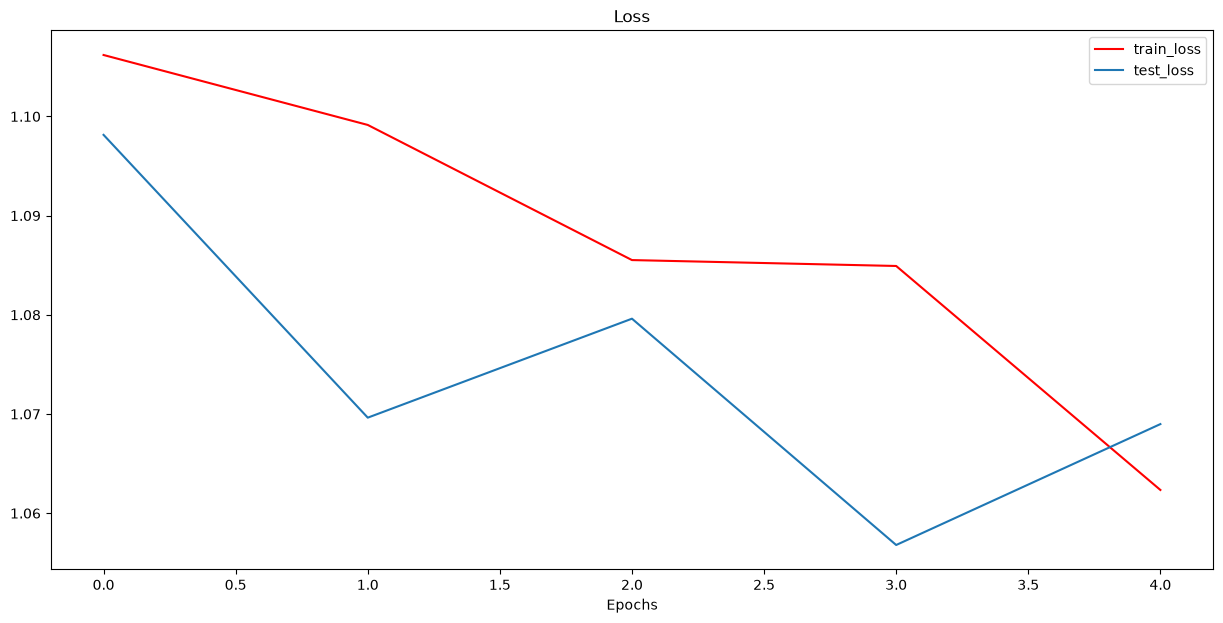

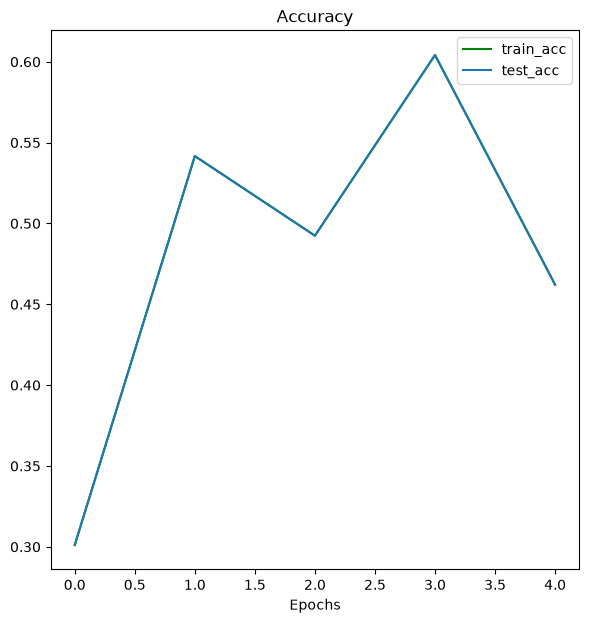

In [103]:
plot_loss_curve(model_0_results)

In [104]:
# TinyVGG with data Augmentation
train_transform_trivial = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=3),
    transforms.ToTensor()
])

test_transform_simple = transforms.Compose([
    transforms.Resize(size = (64, 64)),
    transforms.ToTensor()
])

In [105]:
train_data_augmented = datasets.ImageFolder(root = train_dir, transform = train_transform_trivial)
test_data_simple = datasets.ImageFolder(root = test_dir, transform = test_transform_simple)



In [106]:
batch_size = 32

num_workers = 0
tr.manual_seed(42)

train_data_augmented = DataLoader(dataset = train_data_augmented, batch_size = batch_size, shuffle= True, num_workers= num_workers)
test_dataloader_simple = DataLoader(dataset = test_data_simple, batch_size = batch_size, shuffle=False, num_workers = num_workers)



In [107]:
# construct and train a model_1
tr.manual_seed(42)
model_1 = TinyVGG(input_shape=3, hidden_units=10, output_shape=len(train_data_augmented)).to(device)
model_1


TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=8, bias=True)
  )
)

In [108]:
num_epochs = 5
optimizer = tr.optim.Adam(params=model_1.parameters(), lr = 0.001)

start_time = timer()

model_1_results = train(model = model_1, train_dataloader=train_data_augmented, test_dataloader=test_dataloader_simple, optimizer=optimizer, loss_fn=loss_fn, epochs=num_epochs, device=device)
end_time = timer()
print(start_time - end_time)

  0%|          | 0/5 [00:00<?, ?it/s]

torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([1, 10, 30, 30])
torch.Size([1, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])


 20%|██        | 1/5 [00:01<00:04,  1.22s/it]

torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([11, 10, 30, 30])
torch.Size([11, 10, 13, 13])
Epcoch: 0 | Train Loss: 1.791600063443184  | Train Accuracy :0.25390625 | Test  Loss : 1.3660090764363606 | Test Accuracy :0.4517045454545454
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([1, 10, 30, 30])
torch.Size([1, 10, 13, 13])


 40%|████      | 2/5 [00:02<00:03,  1.18s/it]

...

torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([11, 10, 30, 30])
torch.Size([11, 10, 13, 13])
Epcoch: 2 | Train Loss: 1.1449393332004547  | Train Accuracy :0.28125 | Test  Loss : 1.078281323115031 | Test Accuracy :0.5539772727272728
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([1, 10, 30, 30])
torch.Size([1, 10, 13, 13])


 80%|████████  | 4/5 [00:04<00:01,  1.17s/it]

torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([11, 10, 30, 30])
torch.Size([11, 10, 13, 13])
Epcoch: 3 | Train Loss: 1.1063826084136963  | Train Accuracy :0.3125 | Test  Loss : 1.079042653242747 | Test Accuracy :0.2604166666666667
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([1, 10, 30, 30])
torch.Size([1, 10, 13, 13])
torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])


100%|██████████| 5/5 [00:05<00:00,  1.17s/it]

torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([11, 10, 30, 30])
torch.Size([11, 10, 13, 13])
Epcoch: 4 | Train Loss: 1.1934151276946068  | Train Accuracy :0.3046875 | Test  Loss : 1.1129310329755147 | Test Accuracy :0.2604166666666667
-5.862565399962477


In [109]:
import pandas as pd

In [111]:
model_0_df = pd.DataFrame(model_0_results)
model_1_df = pd.DataFrame(model_1_results)

model_0_df, model_1_df

(   train_loss  train_acc  test_loss  test_acc
 0    1.106193   0.301136   1.098141  0.301136
 1    1.099141   0.541667   1.069632  0.541667
 2    1.085518   0.492424   1.079609  0.492424
 3    1.084923   0.604167   1.056794  0.604167
 4    1.062342   0.462121   1.068983  0.462121,
    train_loss  train_acc  test_loss  test_acc
 0    1.791600   0.451705   1.366009  0.451705
 1    1.182872   0.541667   1.023392  0.541667
 2    1.144939   0.553977   1.078281  0.553977
 3    1.106383   0.260417   1.079043  0.260417
 4    1.193415   0.260417   1.112931  0.260417)

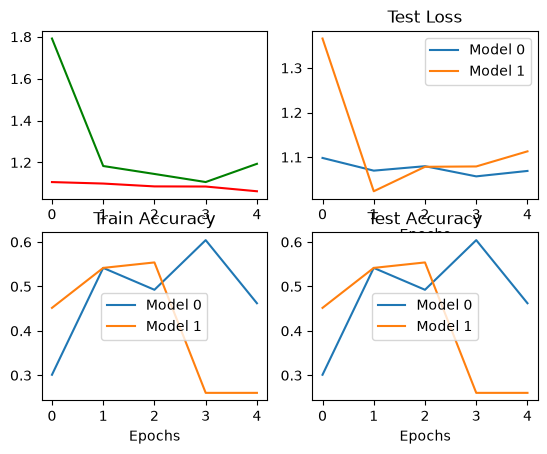

In [112]:
plt.Figure(figsize=(15, 7))
epochs = range(len(model_0_df))

plt.subplot(2,2,1)
plt.plot(epochs, model_0_df["train_loss"], c="r", label = "train_loss0")
plt.plot(epochs, model_1_df["train_loss"], c="g", label = "train_loss1")


# Plot test loss
plt.subplot(2, 2, 2)
plt.plot(epochs, model_0_df["test_loss"], label="Model 0")
plt.plot(epochs, model_1_df["test_loss"], label="Model 1")
plt.title("Test Loss")
plt.xlabel("Epochs")
plt.legend()

# Plot train accuracy
plt.subplot(2, 2, 3)
plt.plot(epochs, model_0_df["train_acc"], label="Model 0")
plt.plot(epochs, model_1_df["train_acc"], label="Model 1")
plt.title("Train Accuracy")
plt.xlabel("Epochs")
plt.legend()

# Plot test accuracy
plt.subplot(2, 2, 4)
plt.plot(epochs, model_0_df["test_acc"], label="Model 0")
plt.plot(epochs, model_1_df["test_acc"], label="Model 1")
plt.title("Test Accuracy")
plt.xlabel("Epochs")
plt.legend();

In [113]:
import torchvision

In [114]:
custom_image_path = image_path 

In [115]:
# make a prediction on custom image

# make a prediction on custom image
# Select a single image file from the directory (e.g., the first .jpg file)
custom_image_path = next(image_path.glob("*.jpg"))
custom_image_uint = torchvision.io.read_image(str(custom_image_path))
custom_image_uint


tensor([[[  0,   0,   0,  ...,  91,  41,  37],
         [  0,   0,   0,  ...,  62,  49,  20],
         [  0,   1,   3,  ...,  33,  50,   3],
         ...,
         [  9,   6,   2,  ...,   8,   8,   8],
         [  7,   3,   1,  ...,   8,   8,   8],
         [  4,   1,   1,  ...,   8,   8,   8]],

        [[  6,   6,   6,  ..., 102,  51,  47],
         [  5,   5,   5,  ...,  73,  59,  30],
         [  4,   3,   4,  ...,  42,  58,  11],
         ...,
         [  8,   5,   0,  ...,   9,   9,   9],
         [  6,   1,   0,  ...,   9,   9,   9],
         [  2,   0,   0,  ...,   9,   9,   9]],

        [[  0,   0,   0,  ..., 108,  53,  49],
         [  0,   0,   0,  ...,  79,  61,  32],
         [  0,   0,   0,  ...,  49,  61,  14],
         ...,
         [  3,   1,   3,  ...,  11,  11,  11],
         [  4,   2,   2,  ...,  11,  11,  11],
         [  3,   2,   4,  ...,  11,  11,  11]]], dtype=torch.uint8)

In [116]:
import matplotlib.pyplot as plt

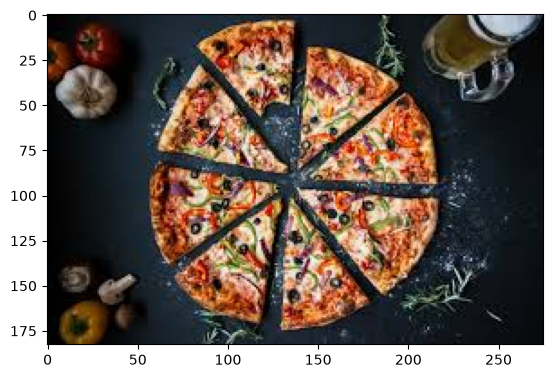

In [117]:
plt.imshow(custom_image_uint.permute(1, 2, 0))

torch.uint8

Making a prediction with custom image with trained PyTorch model


In [118]:
model_1.eval()
with tr.inference_mode():
    model_1(custom_image_uint.to(device))

RuntimeError: Input type (unsigned char) and bias type (float) should be the same

In [121]:
# Load in custom image and convert the tensor values to float32
custom_image = torchvision.io.read_image(str(custom_image_path)).type(tr.float32)

# Divide the image pixel values by 255 to get them between [0, 1]
custom_image = custom_image / 255. 

# Print out image data
print(f"Custom image tensor:\n{custom_image}\n")
print(f"Custom image shape: {custom_image.shape}\n")
print(f"Custom image dtype: {custom_image.dtype}")

Custom image tensor:
tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.3569, 0.1608, 0.1451],
         [0.0000, 0.0000, 0.0000,  ..., 0.2431, 0.1922, 0.0784],
         [0.0000, 0.0039, 0.0118,  ..., 0.1294, 0.1961, 0.0118],
         ...,
         [0.0353, 0.0235, 0.0078,  ..., 0.0314, 0.0314, 0.0314],
         [0.0275, 0.0118, 0.0039,  ..., 0.0314, 0.0314, 0.0314],
         [0.0157, 0.0039, 0.0039,  ..., 0.0314, 0.0314, 0.0314]],

        [[0.0235, 0.0235, 0.0235,  ..., 0.4000, 0.2000, 0.1843],
         [0.0196, 0.0196, 0.0196,  ..., 0.2863, 0.2314, 0.1176],
         [0.0157, 0.0118, 0.0157,  ..., 0.1647, 0.2275, 0.0431],
         ...,
         [0.0314, 0.0196, 0.0000,  ..., 0.0353, 0.0353, 0.0353],
         [0.0235, 0.0039, 0.0000,  ..., 0.0353, 0.0353, 0.0353],
         [0.0078, 0.0000, 0.0000,  ..., 0.0353, 0.0353, 0.0353]],

        [[0.0000, 0.0000, 0.0000,  ..., 0.4235, 0.2078, 0.1922],
         [0.0000, 0.0000, 0.0000,  ..., 0.3098, 0.2392, 0.1255],
         [0.0000, 0.0000, 0.0000,  ..

In [123]:
custom_image_transform = transforms.Compose([
    transforms.Resize((64, 64)),
])

# Transform target image
custom_image_transformed = custom_image_transform(custom_image)

# Print out original shape and new shape
print(f"Original shape: {custom_image.shape}")
print(f"New shape: {custom_image_transformed.shape}")

Original shape: torch.Size([3, 183, 275])
New shape: torch.Size([3, 64, 64])


In [124]:
model_1.eval()
with tr.inference_mode():
    # Add an extra dimension to image
    custom_image_transformed_with_batch_size = custom_image_transformed.unsqueeze(dim=0)
    
    # Print out different shapes
    print(f"Custom image transformed shape: {custom_image_transformed.shape}")
    print(f"Unsqueezed custom image shape: {custom_image_transformed_with_batch_size.shape}")
    
    # Make a prediction on image with an extra dimension
    custom_image_pred = model_1(custom_image_transformed.unsqueeze(dim=0).to(device))

Custom image transformed shape: torch.Size([3, 64, 64])
Unsqueezed custom image shape: torch.Size([1, 3, 64, 64])
torch.Size([1, 10, 30, 30])
torch.Size([1, 10, 13, 13])


In [125]:
# Print out prediction logits
print(f"Prediction logits: {custom_image_pred}")

# Convert logits -> prediction probabilities (using torch.softmax() for multi-class classification)
custom_image_pred_probs = tr.softmax(custom_image_pred, dim=1)
print(f"Prediction probabilities: {custom_image_pred_probs}")

# Convert prediction probabilities -> prediction labels
custom_image_pred_label = tr.argmax(custom_image_pred_probs, dim=1)
print(f"Prediction label: {custom_image_pred_label}")

Prediction logits: tensor([[ 3.6602,  3.3978,  3.5129, -5.8168, -5.9194, -5.8975, -5.9110, -5.7078]])
Prediction probabilities: tensor([[3.7985e-01, 2.9218e-01, 3.2783e-01, 2.9095e-05, 2.6258e-05, 2.6840e-05,
         2.6478e-05, 3.2445e-05]])
Prediction label: tensor([0])


In [126]:
# Find the predicted label
custom_image_pred_class = class_names[custom_image_pred_label.cpu()] # put pred label to CPU, otherwise will error
custom_image_pred_class

'pizza'

In [127]:
# The values of the prediction probabilities are quite similar
custom_image_pred_probs

tensor([[3.7985e-01, 2.9218e-01, 3.2783e-01, 2.9095e-05, 2.6258e-05, 2.6840e-05,
         2.6478e-05, 3.2445e-05]])

In [128]:
def pred_and_plot_image(model: tr.nn.Module, 
                        image_path: str, 
                        class_names: List[str] = None, 
                        transform=None,
                        device: tr.device = device):
    """Makes a prediction on a target image and plots the image with its prediction."""
    
    # 1. Load in image and convert the tensor values to float32
    target_image = torchvision.io.read_image(str(image_path)).type(tr.float32)
    
    # 2. Divide the image pixel values by 255 to get them between [0, 1]
    target_image = target_image / 255. 
    
    # 3. Transform if necessary
    if transform:
        target_image = transform(target_image)
    
    # 4. Make sure the model is on the target device
    model.to(device)
    
    # 5. Turn on model evaluation mode and inference mode
    model.eval()
    with tr.inference_mode():
        # Add an extra dimension to the image
        target_image = target_image.unsqueeze(dim=0)
    
        # Make a prediction on image with an extra dimension and send it to the target device
        target_image_pred = model(target_image.to(device))
        
    # 6. Convert logits -> prediction probabilities (using torch.softmax() for multi-class classification)
    target_image_pred_probs = tr.softmax(target_image_pred, dim=1)

    # 7. Convert prediction probabilities -> prediction labels
    target_image_pred_label = tr.argmax(target_image_pred_probs, dim=1)
    
    # 8. Plot the image alongside the prediction and prediction probability
    plt.imshow(target_image.squeeze().permute(1, 2, 0)) # make sure it's the right size for matplotlib
    if class_names:
        title = f"Pred: {class_names[target_image_pred_label.cpu()]} | Prob: {target_image_pred_probs.max().cpu():.3f}"
    else: 
        title = f"Pred: {target_image_pred_label} | Prob: {target_image_pred_probs.max().cpu():.3f}"
    plt.title(title)
    plt.axis(False);

torch.Size([1, 10, 30, 30])
torch.Size([1, 10, 13, 13])


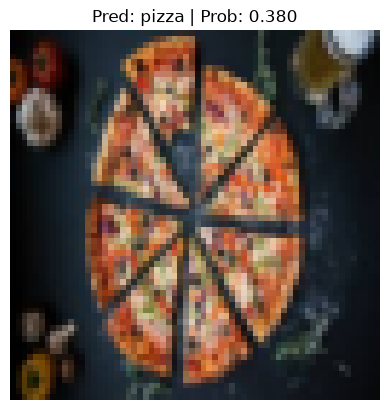

In [129]:

# Pred on our custom image
pred_and_plot_image(model=model_1,
                    image_path=custom_image_path,
                    class_names=class_names,
                    transform=custom_image_transform,
                    device=device)